# Member 2 — Tennakoon T.A.K. S
IT25103321 · DuplicateRemoval

This notebook demonstrates this member’s technique using the shared integrated recipe. Run `group_pipeline.ipynb` for every stage and final exports.

## 01 · Load and inspect the assigned diabetes data

Eight input fields plus target `diabetes`. The reference Framingham columns are not copied.

In [1]:
from pathlib import Path
import sys, os
# In Colab: upload/extract the COMPLETE corrected project ZIP first.
# If needed set PROJECT_ROOT = Path('/content/MLB-B9G2-06').
PROJECT_ROOT = next((p for base in [Path.cwd(), *Path.cwd().parents, Path('/content')]
                     for p in [base, base/'MLB-B9G2-06']
                     if (p/'src/project_core.py').exists()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Extract the complete project ZIP and set PROJECT_ROOT above.')
sys.path.insert(0, str(PROJECT_ROOT/'src'))
from project_core import *
from IPython.display import display
from threadpoolctl import threadpool_limits
thread_limit = threadpool_limits(limits=2)
raw, clean, X_train, X_test, y_train, y_test = load_dataset(PROJECT_ROOT)
print('Raw / clean / train / test:', len(raw), len(clean), len(X_train), len(X_test))

display(raw.head())
display(raw.dtypes.to_frame("dtype"))
display(raw.describe(include="all").T)

Raw / clean / train / test: 100000 96146 76916 19230


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


,dtype
gender,object
age,float64
hypertension,int64
heart_disease,int64
smoking_history,object
bmi,float64
HbA1c_level,float64
blood_glucose_level,int64
diabetes,int64


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gender,100000,3,Female,58552,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,100000.0,NaN,NaN,NaN,41.885856,22.51684,0.08,24.0,43.0,60.0,80.0
hypertension,100000.0,NaN,NaN,NaN,0.07485,0.26315,0.0,0.0,0.0,0.0,1.0
heart_disease,100000.0,NaN,NaN,NaN,0.03942,0.194593,0.0,0.0,0.0,0.0,1.0
smoking_history,100000,6,No Info,35816,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,100000.0,NaN,NaN,NaN,27.320767,6.636783,10.01,23.63,27.32,29.58,95.69
HbA1c_level,100000.0,NaN,NaN,NaN,5.527507,1.070672,3.5,4.8,5.8,6.2,9.0
blood_glucose_level,100000.0,NaN,NaN,NaN,138.05806,40.708136,80.0,100.0,140.0,159.0,300.0
diabetes,100000.0,NaN,NaN,NaN,0.085,0.278883,0.0,0.0,0.0,0.0,1.0


## 03 · Member 2 — exact duplicate removal

Deduplicate full rows before splitting. Original raw-row IDs remain the index. This counts records, not verified unique patients.

Duplicates removed: 3854 ; remaining: 96146


,raw,clean
diabetes,,
0,91500,87664
1,8500,8482


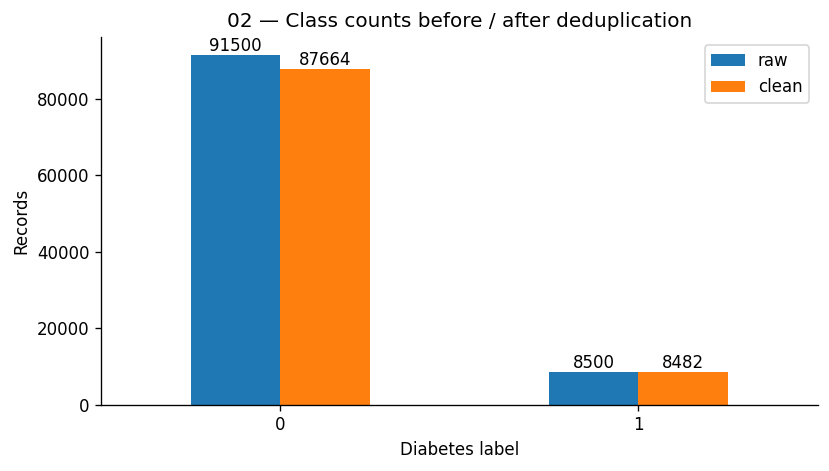

In [2]:
duplicates=int(raw.duplicated().sum())
print('Duplicates removed:',duplicates,'; remaining:',len(clean))
assert not clean.duplicated().any()
clean.to_csv(PROJECT_ROOT/'results/outputs/01_cleaned_deduplicated.csv',index_label='raw_row_id')
counts=pd.DataFrame({'raw':raw.diabetes.value_counts(),'clean':clean.diabetes.value_counts()}).sort_index()
display(counts)
ax=counts.plot.bar(figsize=(7,4),rot=0);ax.set(xlabel='Diabetes label',ylabel='Records',title='02 — Class counts before / after deduplication')
for c in ax.containers:ax.bar_label(c,fmt='%d')
savefig(PROJECT_ROOT,'02_duplicates_classes')